<a href="https://colab.research.google.com/github/Marwan77770/codealpha_tasks/blob/main/mnist_neural_network_executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import urllib.request
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1782784123.841863     654 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782784123.884653     654 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782784125.695467     654 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## 2. Load and Preprocess the Dataset



In [ ]:
def load_mnist_from_idx_mirror():
    """Fallback loader: downloads the original IDX-format MNIST files
    from a GitHub mirror and parses them manually."""
    base_url = "https://raw.githubusercontent.com/fgnt/mnist/master/"
    files = {
        'train_images': 'train-images-idx3-ubyte.gz',
        'train_labels': 'train-labels-idx1-ubyte.gz',
        'test_images': 't10k-images-idx3-ubyte.gz',
        'test_labels': 't10k-labels-idx1-ubyte.gz',
    }

    os.makedirs('mnist_data', exist_ok=True)
    local_paths = {}
    for key, fname in files.items():
        local_path = os.path.join('mnist_data', fname)
        if not os.path.exists(local_path):
            urllib.request.urlretrieve(base_url + fname, local_path)
        local_paths[key] = local_path

    def _load_images(path):
        with gzip.open(path, 'rb') as f:
            data = f.read()
        _, n, rows, cols = np.frombuffer(data[:16], dtype='>i4')
        return np.frombuffer(data[16:], dtype=np.uint8).reshape(n, rows, cols)

    def _load_labels(path):
        with gzip.open(path, 'rb') as f:
            data = f.read()
        _, n = np.frombuffer(data[:8], dtype='>i4')
        return np.frombuffer(data[8:], dtype=np.uint8)

    x_train = _load_images(local_paths['train_images'])
    y_train = _load_labels(local_paths['train_labels'])
    x_test = _load_images(local_paths['test_images'])
    y_test = _load_labels(local_paths['test_labels'])
    return (x_train, y_train), (x_test, y_test)


try:
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
    print("Loaded MNIST using keras.datasets.mnist.")
except Exception as e:
    print(f"keras.datasets.mnist failed ({e}). Falling back to GitHub mirror...")
    (x_train, y_train), (x_test, y_test) = load_mnist_from_idx_mirror()
    print("Loaded MNIST using the GitHub IDX mirror.")

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

keras.datasets.mnist failed (URL fetch failure on https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz: 403 -- Forbidden). Falling back to GitHub mirror...


Loaded MNIST using the GitHub IDX mirror.
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


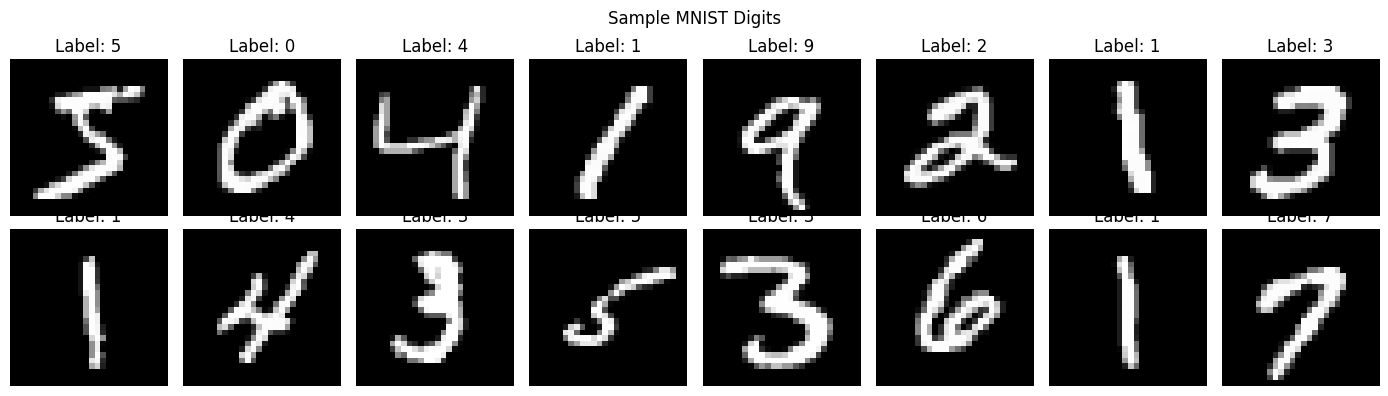

In [ ]:
# Visualize a sample of the digits
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle('Sample MNIST Digits')
plt.tight_layout()
plt.show()

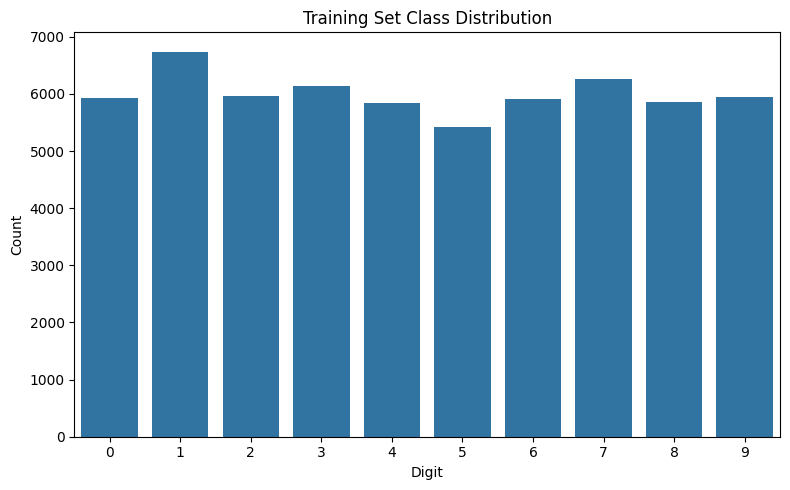

In [ ]:
# Class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train)
plt.title('Training Set Class Distribution')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Preprocessing



In [ ]:
# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten 28x28 images into 784-length vectors
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print("x_train_flat shape:", x_train_flat.shape)
print("x_test_flat shape:", x_test_flat.shape)
print("Pixel value range after normalization:", x_train_flat.min(), "-", x_train_flat.max())

x_train_flat shape: (60000, 784)
x_test_flat shape: (10000, 784)
Pixel value range after normalization: 0.0 - 1.0


## 3. Design the Neural Network Architecture



In [ ]:
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu', name='hidden_layer_1'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu', name='hidden_layer_2'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax', name='output_layer')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 4. Train the Model Using Backpropagation



In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_train_flat, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=2
)

Epoch 1/30


375/375 - 3s - 8ms/step - accuracy: 0.8918 - loss: 0.3661 - val_accuracy: 0.9594 - val_loss: 0.1402


Epoch 2/30


375/375 - 2s - 5ms/step - accuracy: 0.9548 - loss: 0.1520 - val_accuracy: 0.9663 - val_loss: 0.1081


Epoch 3/30


...

375/375 - 3s - 7ms/step - accuracy: 0.9859 - loss: 0.0435 - val_accuracy: 0.9781 - val_loss: 0.0828


Epoch 9/30


375/375 - 3s - 7ms/step - accuracy: 0.9856 - loss: 0.0421 - val_accuracy: 0.9765 - val_loss: 0.0852


Epoch 10/30


375/375 - 3s - 7ms/step - accuracy: 0.9886 - loss: 0.0353 - val_accuracy: 0.9774 - val_loss: 0.0864


## 5. Visualize Training/Validation Loss and Accuracy

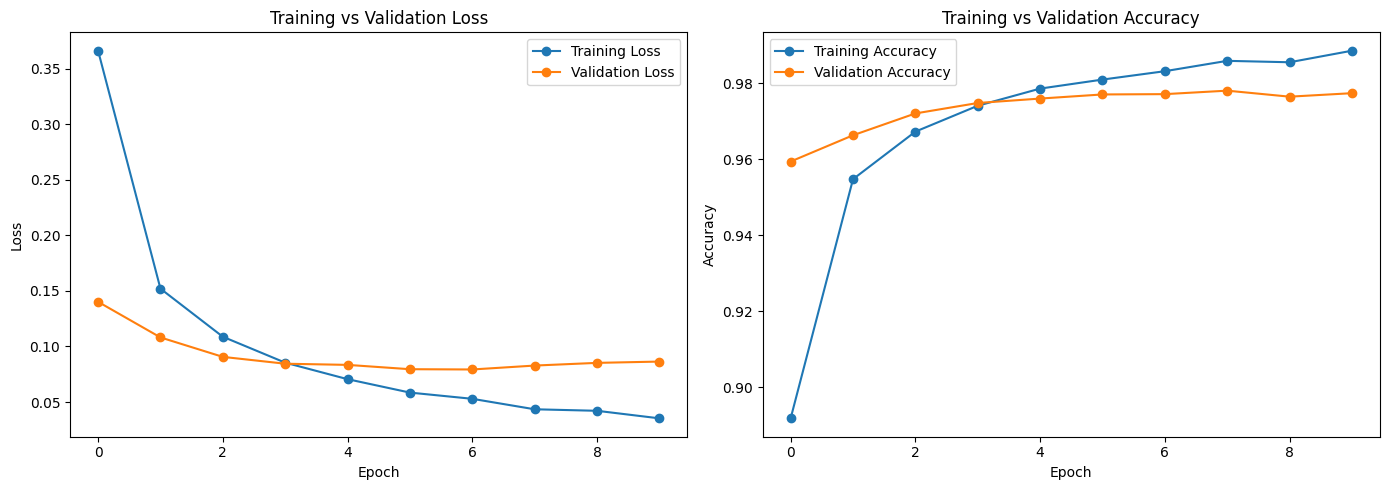

In [ ]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df['loss'], label='Training Loss', marker='o')
axes[0].plot(history_df['val_loss'], label='Validation Loss', marker='o')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_df['accuracy'], label='Training Accuracy', marker='o')
axes[1].plot(history_df['val_accuracy'], label='Validation Accuracy', marker='o')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Evaluate the Model on the Test Set

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=0)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss:     0.0697
Test Accuracy: 0.9792


In [ ]:
y_pred_probs = model.predict(x_test_flat, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:

              precision    recall  f1-score   support

           0     0.9789    0.9929    0.9858       980
           1     0.9877    0.9930    0.9903      1135
           2     0.9795    0.9738    0.9767      1032
           3     0.9754    0.9802    0.9778      1010
           4     0.9777    0.9807    0.9792       982
           5     0.9744    0.9809    0.9777       892
           6     0.9801    0.9770    0.9786       958
           7     0.9805    0.9767    0.9786      1028
           8     0.9771    0.9641    0.9705       974
           9     0.9790    0.9713    0.9751      1009

    accuracy                         0.9792     10000
   macro avg     0.9790    0.9790    0.9790     10000
weighted avg     0.9792    0.9792    0.9792     10000



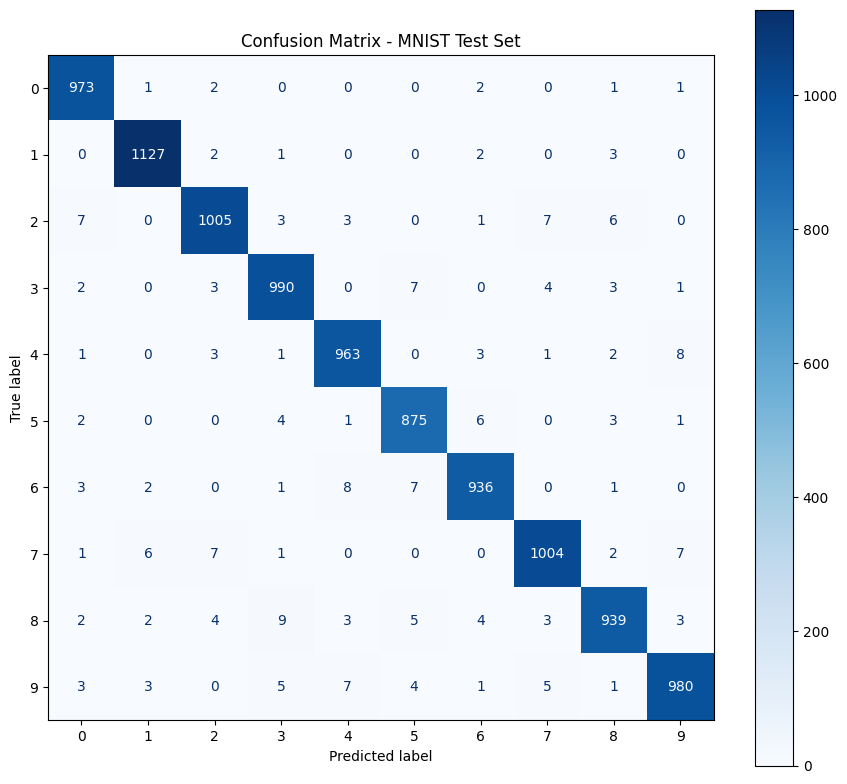

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title('Confusion Matrix - MNIST Test Set')
plt.tight_layout()
plt.show()

Total misclassified samples: 208 out of 10000


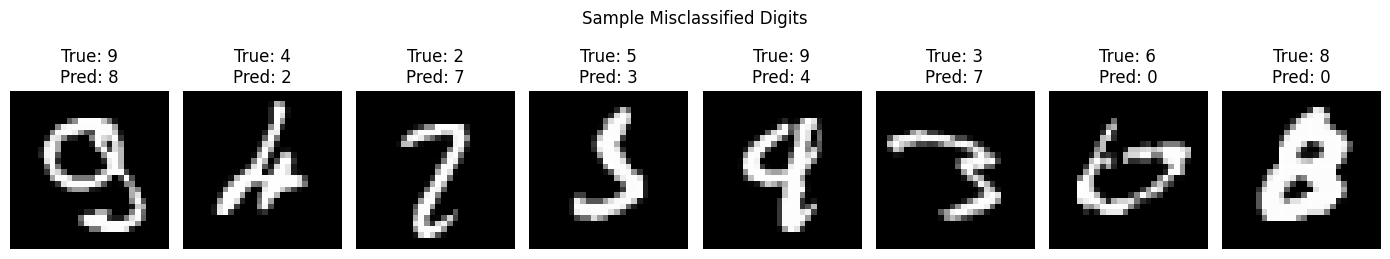

In [ ]:
# Inspect a sample of misclassified digits
misclassified_idx = np.where(y_pred != y_test)[0]
print(f"Total misclassified samples: {len(misclassified_idx)} out of {len(y_test)}")

n_show = min(8, len(misclassified_idx))
fig, axes = plt.subplots(1, n_show, figsize=(14, 3))
for i, idx in enumerate(misclassified_idx[:n_show]):
    axes[i].imshow(x_test[idx], cmap='gray')
    axes[i].set_title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}")
    axes[i].axis('off')
plt.suptitle('Sample Misclassified Digits')
plt.tight_layout()
plt.show()